###Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from textblob import TextBlob

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

###Load Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
url = "/content/drive/MyDrive/trumptweets_small.csv"
df = pd.read_csv(url)

df = df[['content']]
df.columns = ['tweet']

df.head()

,tweet
0,Be sure to tune in and watch Donald Trump on L...
1,Donald Trump will be appearing on The View tom...
2,Donald Trump reads Top Ten Financial Tips on L...
3,New Blog Post: Celebrity Apprentice Finale and...
4,"""My persona will never be that of a wallflower..."


###Sentiment Labeling

In [4]:
def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    return 1 if polarity > 0 else 0

df['label'] = df['tweet'].apply(get_sentiment)
df.head()

,tweet,label
0,Be sure to tune in and watch Donald Trump on L...,1
1,Donald Trump will be appearing on The View tom...,1
2,Donald Trump reads Top Ten Financial Tips on L...,1
3,New Blog Post: Celebrity Apprentice Finale and...,1
4,"""My persona will never be that of a wallflower...",0


###Text Preprocessing

In [5]:
def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.strip()

    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    text = " ".join([
        lemmatizer.lemmatize(word)
        for word in text.split()
        if word not in stop_words
    ])
    return text

print("Cleaning tweets...")
df['cleaned_tweet'] = df['tweet'].apply(clean_tweet)

Cleaning tweets...


###WordCloud Visualization

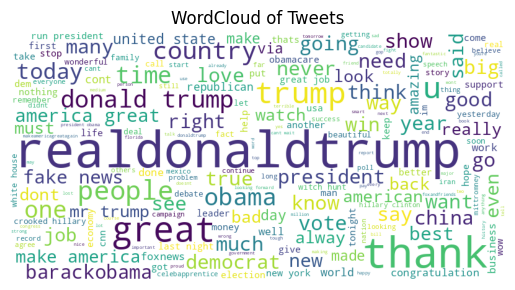

In [6]:
all_words = ' '.join(df['cleaned_tweet'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.imshow(wordcloud)
plt.axis('off')
plt.title("WordCloud of Tweets")
plt.show()

###Train/Test Split + Tokenization

In [7]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['cleaned_tweet'], df['label'], test_size=0.2, random_state=42
)

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_raw)

X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq = tokenizer.texts_to_sequences(X_test_raw)

max_length = int(np.percentile([len(x) for x in X_train_seq], 95))

X_train_padded = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_length, padding='post')

###LSTM Model

In [8]:
model = Sequential([

    Embedding(10000, 128, input_length=max_length),

    LSTM(64),

    Dense(1, activation='sigmoid')

])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Training

In [9]:
early_stop = EarlyStopping(patience=2, restore_best_weights=True)

history = model.fit(
    X_train_padded, y_train,
    epochs=10,
    validation_data=(X_test_padded, y_test),
    callbacks=[early_stop],
    batch_size=32
)

Epoch 1/10
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 39s 35ms/step - accuracy: 0.8518 - loss: 0.3392 - val_accuracy: 0.9134 - val_loss: 0.2434
Epoch 2/10
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 69s 63ms/step - accuracy: 0.9391 - loss: 0.1764 - val_accuracy: 0.9145 - val_loss: 0.2322
Epoch 3/10
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 33s 32ms/step - accuracy: 0.9594 - loss: 0.1245 - val_accuracy: 0.9165 - val_loss: 0.2669
Epoch 4/10
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.9716 - loss: 0.0873 - val_accuracy: 0.9089 - val_loss: 0.2874


###Evaluation

In [10]:
y_pred = (model.predict(X_test_padded) > 0.5).astype("int32")

print(classification_report(y_test, y_pred))

258/258 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
              precision    recall  f1-score   support

           0       0.93      0.87      0.90      3639
           1       0.90      0.95      0.93      4586

    accuracy                           0.91      8225
   macro avg       0.92      0.91      0.91      8225
weighted avg       0.92      0.91      0.91      8225



###Confusion Matrix

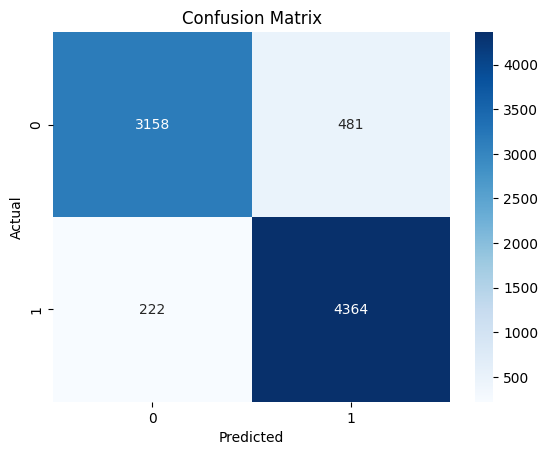

In [11]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()